# Exercise 2. 사이버 리스크 회귀
`risk_score`를 예측하며 선형회귀, Ridge, Lasso, KNN, 의사결정나무, 랜덤포레스트, Gradient Boosting을 비교합니다. MAE·MSE·RMSE·MAPE·R², 잔차, 과대적합을 학습합니다.

In [1]:
# ============================================================
# 1번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 실행에 영향을 주지 않는 경고 메시지를 관리하기 위해 warnings 모듈을 불러옵니다.
import warnings, os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt

# 실습 화면을 복잡하게 만드는 경고 메시지를 숨깁니다.
warnings.filterwarnings("ignore")

# 아래 명령을 실행하여 현재 단계의 데이터 처리 또는 분석을 수행합니다.
from IPython.display import display

# 실행할 때마다 동일한 결과가 나오도록 난수 기준값을 고정합니다.
RANDOM_STATE=42

# NumPy에서 생성되는 난수도 동일하게 재현되도록 고정합니다.
np.random.seed(RANDOM_STATE)

# 데이터프레임을 출력할 때 표시되는 행이나 열의 개수를 조정합니다.
pd.set_option("display.max_columns",100)

# 현재 처리 결과를 사용자가 확인할 수 있도록 화면에 출력합니다.
print("환경 준비 완료")

환경 준비 완료


In [2]:
# ============================================================
# 2번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 자동으로 찾을 CSV 파일 이름에 포함된 핵심 단어를 지정합니다.
EXPECTED_KEYWORD="cyber_risk_sample"
# 지정한 폴더에서 CSV 파일 목록을 검색합니다.
paths=(glob.glob("/content/*.csv")+glob.glob("/content/drive/MyDrive/**/*.csv",recursive=True)
       # 지정한 폴더에서 CSV 파일 목록을 검색합니다.
       +glob.glob("./*.csv")+glob.glob("/mnt/data/*.csv"))
# 검색된 파일 중 핵심 단어가 포함된 파일만 선택합니다.
matched=[p for p in paths if EXPECTED_KEYWORD.lower() in os.path.basename(p).lower()]

# 자동으로 파일을 찾지 못했을 때만 직접 업로드를 실행합니다
if not matched:
    # 아래 명령을 실행하여 현재 단계의 데이터 처리 또는 분석을 수행합니다.
    from google.colab import files
    # 현재 처리 결과를 사용자가 확인할 수 있도록 화면에 출력합니다.
    print("CSV 파일을 업로드하세요.")
    # Colab의 파일 선택 창을 열어 사용자가 CSV 파일을 업로드하게 합니다.
    uploaded=files.upload()
    # 검색된 파일 중 핵심 단어가 포함된 파일만 선택합니다.
    matched=list(uploaded.keys())

# 찾은 파일 중 첫 번째 파일의 경로를 저장합니다.
file_path=matched[0]
# CSV 파일을 읽어 pandas 데이터프레임으로 변환합니다.
df=pd.read_csv(file_path)

# 현재 처리 결과를 사용자가 확인할 수 있도록 화면에 출력합니다.
print("파일:",file_path,"크기:",df.shape)
# 데이터가 정상적으로 불러와졌는지 앞부분을 표로 확인합니다.
display(df.head())

CSV 파일을 업로드하세요.


Saving Exercise2. cyber_risk_sample.csv to Exercise2. cyber_risk_sample.csv
파일: Exercise2. cyber_risk_sample.csv 크기: (3000, 16)


,scenario_id,scenario_type,asset_type,threat_category,vulnerability_score,asset_importance,exposure_level,security_maturity,control_effectiveness,threat_intensity,incident_likelihood,data_sensitivity,estimated_financial_impact,risk_score,risk_level,response_priority
0,RISK-0001,Credential Compromise,Endpoint PC,Phishing,3.75,3,7,8,5,8,0.47,5,2432029,97.88,High,1순위
1,RISK-0002,Insider Threat,Web Server,Brute Force,9.51,9,2,5,2,3,0.83,4,1546223,100.00,High,1순위
2,RISK-0003,Credential Compromise,Endpoint PC,C2 Communication,7.32,5,2,9,9,1,0.81,1,1312515,56.04,Medium,2순위
3,RISK-0004,External Attack,Cloud Service,Data Exfiltration,5.99,8,10,10,1,1,0.51,5,2717245,100.00,High,1순위
4,RISK-0005,Insider Threat,Database Server,Brute Force,1.56,7,10,5,2,1,0.69,10,2717606,100.00,High,1순위


## 1. 데이터 품질과 이상값 탐색

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   scenario_id                 3000 non-null   object 
 1   scenario_type               3000 non-null   object 
 2   asset_type                  3000 non-null   object 
 3   threat_category             3000 non-null   object 
 4   vulnerability_score         3000 non-null   float64
 5   asset_importance            3000 non-null   int64  
 6   exposure_level              3000 non-null   int64  
 7   security_maturity           3000 non-null   int64  
 8   control_effectiveness       3000 non-null   int64  
 9   threat_intensity            3000 non-null   int64  
 10  incident_likelihood         3000 non-null   float64
 11  data_sensitivity            3000 non-null   int64  
 12  estimated_financial_impact  3000 non-null   int64  
 13  risk_score                  3000 

,결측치
scenario_id,0
scenario_type,0
asset_type,0
threat_category,0
vulnerability_score,0
asset_importance,0
exposure_level,0
security_maturity,0
control_effectiveness,0
threat_intensity,0


,count,mean,std,min,25%,50%,75%,max
risk_score,3000.0,89.77846,17.865426,0.0,84.7875,100.0,100.0,100.0


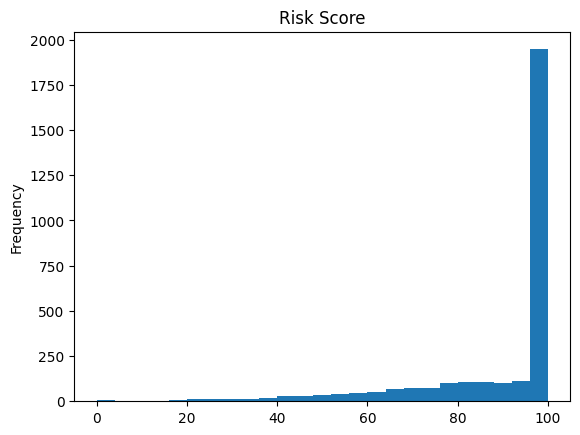

,Feature,IQR_Outliers
9,risk_score,288
8,estimated_financial_impact,7
1,asset_importance,0
0,vulnerability_score,0
2,exposure_level,0
3,security_maturity,0
5,threat_intensity,0
4,control_effectiveness,0
7,data_sensitivity,0
6,incident_likelihood,0


In [3]:
# ============================================================
# 3번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 행 수, 컬럼 이름, 자료형, 결측값 여부 등 데이터 구조를 확인합니다.
print(df.info()); print("중복:",df.duplicated().sum())
# 컬럼별 결측값 개수를 계산합니다.
display(df.isnull().sum().sort_values(ascending=False).head(10).to_frame("결측치"))
# 계산된 표를 보기 좋은 데이터프레임 형태로 화면에 출력합니다.
display(df["risk_score"].describe().to_frame().T)
# 완성된 그래프를 화면에 출력합니다.
df["risk_score"].plot(kind="hist",bins=25,title="Risk Score"); plt.show()

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
rows=[]

# 숫자로 저장된 수치형 컬럼만 선택합니다.
for c in df.select_dtypes(include=np.number):

 # 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
 q1,q3=df[c].quantile([.25,.75]); i=q3-q1

 # 아래 명령을 실행하여 현재 단계의 데이터 처리 또는 분석을 수행합니다.
 rows.append([c,((df[c]<q1-1.5*i)|(df[c]>q3+1.5*i)).sum()])

# 계산된 표를 보기 좋은 데이터프레임 형태로 화면에 출력합니다.
display(pd.DataFrame(rows,columns=["Feature","IQR_Outliers"]).sort_values("IQR_Outliers",ascending=False).head(10))

## 2. 데이터 누수 제거와 전처리
`scenario_id`는 식별자, `risk_level`과 `response_priority`는 위험점수에서 파생될 수 있으므로 제외합니다.

In [4]:
# ============================================================
# 4번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 데이터를 모델 학습용과 최종 평가용으로 나눕니다.
from sklearn.model_selection import train_test_split

# 수치형과 범주형 컬럼에 서로 다른 전처리를 적용합니다.

from sklearn.compose import ColumnTransformer
# 변수마다 단위가 다른 문제를 줄이기 위해 값을 표준화합니다.

from sklearn.preprocessing import OneHotEncoder,StandardScaler
# 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.

from sklearn.impute import SimpleImputer
# 전처리와 모델 학습 단계를 정해진 순서로 묶어 한 번에 실행합니다.

from sklearn.pipeline import Pipeline
# 모델 학습에 사용하지 않을 식별자 또는 정답 컬럼을 제거합니다.

X=df.drop(columns=["risk_score","scenario_id","risk_level","response_priority"]); y=df["risk_score"]
# 숫자로 저장된 수치형 컬럼만 선택합니다.

num=X.select_dtypes(include=np.number).columns; cat=X.select_dtypes(exclude=np.number).columns
# 수치형과 범주형 컬럼에 서로 다른 전처리를 적용합니다.

prep=ColumnTransformer([

# 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
("num",Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())]),num),

# 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cat)])

# 데이터를 모델 학습용과 최종 평가용으로 나눕니다.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=RANDOM_STATE)

## 3. 여러 회귀 모델

In [5]:
# ============================================================
# 5번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 입력 변수와 목표값의 선형 관계를 학습하는 기본 회귀 모델입니다.
from sklearn.linear_model import LinearRegression,Ridge,Lasso

# 가까운 데이터들의 목표값을 참고하여 예측하는 KNN 회귀 모델입니다.
from sklearn.neighbors import KNeighborsRegressor

# 조건 분기를 통해 연속적인 값을 예측하는 회귀 의사결정나무입니다.
from sklearn.tree import DecisionTreeRegressor

# 여러 회귀 나무의 예측 평균을 사용하는 랜덤포레스트 회귀 모델입니다.
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

# 입력 변수와 목표값의 선형 관계를 학습하는 기본 회귀 모델입니다.
ests={"Linear":LinearRegression(),"Ridge":Ridge(),"Lasso":Lasso(alpha=.01,max_iter=10000),

# 가까운 데이터들의 목표값을 참고하여 예측하는 KNN 회귀 모델입니다.
"KNN":KNeighborsRegressor(),"Decision Tree":DecisionTreeRegressor(max_depth=6,random_state=RANDOM_STATE),

# 여러 회귀 나무의 예측 평균을 사용하는 랜덤포레스트 회귀 모델입니다.
"Random Forest":RandomForestRegressor(n_estimators=200,n_jobs=-1,random_state=RANDOM_STATE),

# 앞선 모델의 오차를 다음 모델이 순차적으로 보완하는 부스팅 모델입니다.
"Gradient Boosting":GradientBoostingRegressor(random_state=RANDOM_STATE)}

# 전처리와 모델 학습 단계를 정해진 순서로 묶어 한 번에 실행합니다.
models={n:Pipeline([("prep",prep),("m",m)]) for n,m in ests.items()}

## 4. MAE·MSE·RMSE·MAPE·R² 비교
RMSE는 큰 오차에 더 민감하며, Train R²와 Test R² 차이가 크면 과대적합 가능성이 있습니다.

,Model,Train_R2,Test_R2,MAE,MSE,RMSE,MAPE
6,Gradient Boosting,0.9170,0.8703,4.7374,42.6205,6.5284,4.637222e+15
5,Random Forest,0.9775,0.8373,4.7833,53.4778,7.3129,8.470933e+15
3,KNN,0.8846,0.8338,4.5318,54.6052,7.3895,2.476229e+16
0,Linear,0.6928,0.7147,7.6224,93.7318,9.6815,3.168908e+16
1,Ridge,0.6928,0.7147,7.6224,93.7383,9.6819,3.169894e+16
2,Lasso,0.6928,0.7147,7.6241,93.7392,9.6819,3.178390e+16
4,Decision Tree,0.8185,0.7077,5.9543,96.0639,9.8012,3.196055e+15


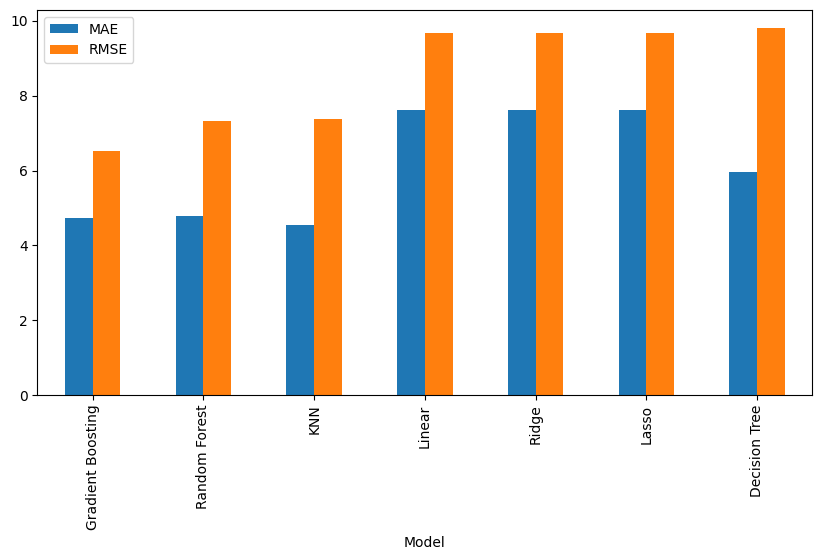

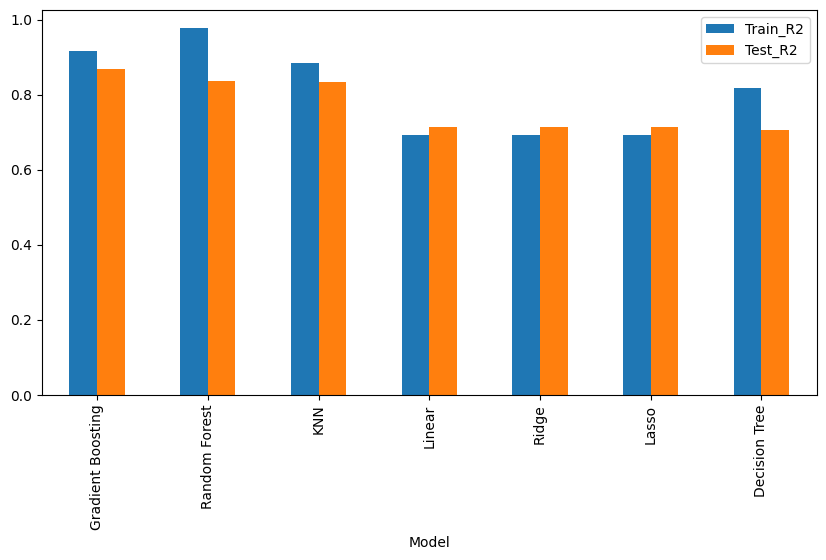

In [6]:
# ============================================================
# 6번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 아래 명령을 실행하여 현재 단계의 데이터 처리 또는 분석을 수행합니다.
from sklearn.metrics import *

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
rows=[]; predictions={}

# 여러 모델이나 여러 설정값을 하나씩 반복해서 처리하기 위한 반복문입니다.
for n,m in models.items():

 # 주어진 학습 데이터의 패턴을 모델이 학습하도록 합니다.
 m.fit(X_train,y_train); tr=m.predict(X_train); p=m.predict(X_test); predictions[n]=p

 # 실제값과 예측값 차이의 절댓값 평균인 MAE를 계산합니다.
 rows.append([n,r2_score(y_train,tr),r2_score(y_test,p),mean_absolute_error(y_test,p),

              # 큰 오차에 더 큰 벌점을 주는 평균제곱오차를 계산합니다.
 mean_squared_error(y_test,p),mean_squared_error(y_test,p)**.5,mean_absolute_percentage_error(y_test,p)*100])

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
result=pd.DataFrame(rows,columns=["Model","Train_R2","Test_R2","MAE","MSE","RMSE","MAPE"]).sort_values("RMSE")

# 계산된 표를 보기 좋은 데이터프레임 형태로 화면에 출력합니다.
display(result.round(4))

# 완성된 그래프를 화면에 출력합니다.
result.set_index("Model")[["MAE","RMSE"]].plot(kind="bar",figsize=(10,5)); plt.show()

# 완성된 그래프를 화면에 출력합니다.
result.set_index("Model")[["Train_R2","Test_R2"]].plot(kind="bar",figsize=(10,5)); plt.show()

## 5. 실제값-예측값 및 잔차 분석

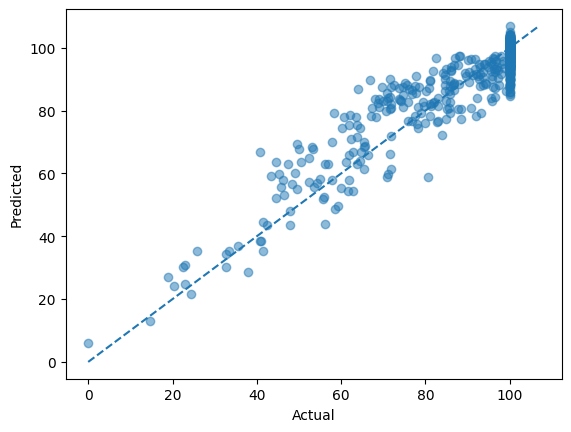

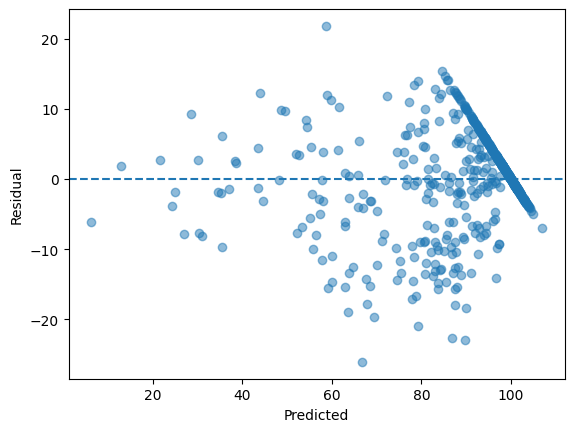

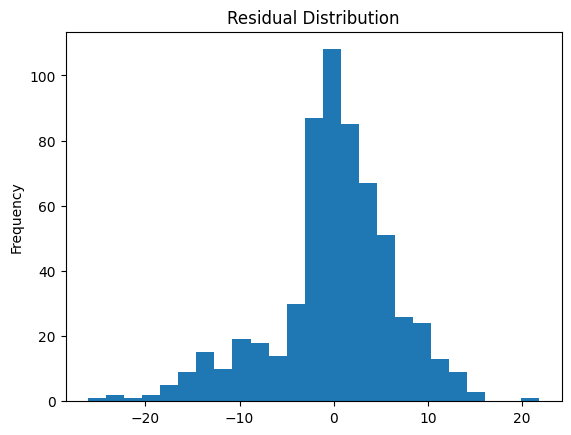

In [7]:
# ============================================================
# 7번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
best=result.iloc[0]["Model"]; p=predictions[best]

# 두 변수의 관계나 데이터 분포를 점 형태의 산점도로 그립니다.
plt.scatter(y_test,p,alpha=.5); lo=min(y_test.min(),p.min()); hi=max(y_test.max(),p.max()); plt.plot([lo,hi],[lo,hi],"--"); plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.show()

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
res=y_test.to_numpy()-p

# 두 변수의 관계나 데이터 분포를 점 형태의 산점도로 그립니다.
plt.scatter(p,res,alpha=.5); plt.axhline(0,ls="--"); plt.xlabel("Predicted"); plt.ylabel("Residual"); plt.show()

# 완성된 그래프를 화면에 출력합니다.
pd.Series(res).plot(kind="hist",bins=25,title="Residual Distribution"); plt.show()

## 7. 특성 중요도

,Feature,Importance
8,num__estimated_financial_impact,0.576139
0,num__vulnerability_score,0.162730
5,num__threat_intensity,0.063522
2,num__exposure_level,0.062329
3,num__security_maturity,0.030504
4,num__control_effectiveness,0.022706
6,num__incident_likelihood,0.020832
1,num__asset_importance,0.015511
7,num__data_sensitivity,0.014449
9,cat__scenario_type_Credential Compromise,0.002347


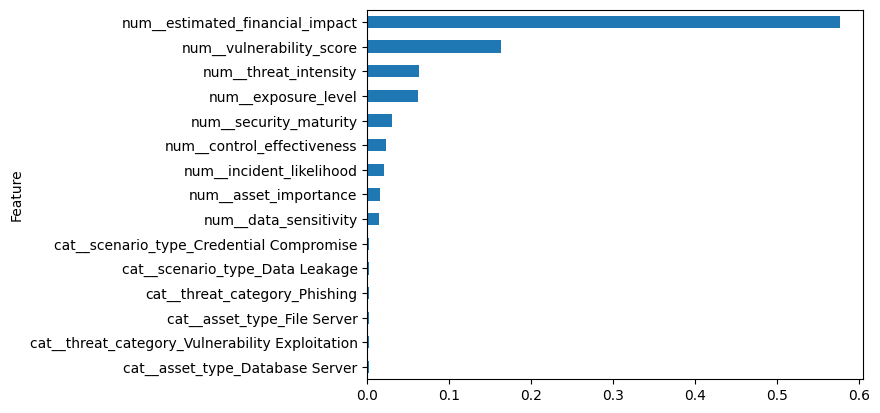

In [8]:
# ============================================================
# 8번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 주어진 학습 데이터의 패턴을 모델이 학습하도록 합니다.
rf=models["Random Forest"].fit(X_train,y_train); fn=rf.named_steps["prep"].get_feature_names_out()

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
imp=pd.DataFrame({"Feature":fn,"Importance":rf.named_steps["m"].feature_importances_}).sort_values("Importance",ascending=False).head(15)

# 완성된 그래프를 화면에 출력합니다.
display(imp); imp.sort_values("Importance").plot(x="Feature",y="Importance",kind="barh",legend=False); plt.show()

In [10]:
# ============================================================
# 9번째 코드 셀: 사이버 리스크 회귀 실습 코드 상세 설명
# ============================================================

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
output_path="/content/exercise2_results.csv" if os.path.isdir("/content") else "./exercise2_results.csv"

# 최종 결과를 나중에 다시 확인할 수 있도록 CSV 파일로 저장합니다.
result.to_csv(output_path,index=False,encoding="utf-8-sig"); print("저장 완료")

저장 완료
